# Ukrainian Folk Songs — Pre-build Data Exploration

Exploration of the 11 Ukrainian folk-song collections from
[Zenodo record 18834301](https://zenodo.org/records/18834301) before the
Song Map platform is built. The corpus contains **8 collections of epic
*dumy*** and **3 Podillia-region collections**, each with a paired
`-metadata.csv` and `-texts.csv` file.

The same patterns apply once the Estonian / Finnish / Karelian / Ingrian
corpora are added — re-point `DATA_DIR`, re-run. Only the
column-translation map and the orthographic probes are
Ukrainian-specific.

**Questions this notebook answers:**

1. What files do we have, and how do they pair up?
2. What's in the metadata — genres, years, regions, singers, collectors?
3. What's in the text — length, vocabulary, orthographic variation?
4. Where are the data-quality holes we must patch before NLP?
5. Baselines for the downstream tasks (themes, sentiment, similarity).


## 0. Setup

In [7]:
import re
import csv
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Point this at the folder holding the Zenodo CSVs.
DATA_DIR = Path("ukranian-songs")
assert DATA_DIR.exists(), f"Create {DATA_DIR} and drop the Zenodo CSVs there."


## 1. File inventory — pair metadata with texts

Filenames on Zenodo are inconsistent (some use `-metadata.csv`, some
` - metadata.csv`, some `_metadata.csv`). Classify robustly and check
every collection has both sides of the pair.


In [8]:
# Optional — download the whole Zenodo record if the folder is empty.
# Skip this cell if you already have the files locally.
def download_zenodo_record(record_id: str, target: Path):
    import requests
    target.mkdir(parents=True, exist_ok=True)
    meta = requests.get(f"https://zenodo.org/api/records/{record_id}").json()
    for f in meta["files"]:
        out = target / f["key"]
        if out.exists():
            continue
        print(f"Downloading {f['key']} ({f['size']/1e6:.1f} MB)")
        with requests.get(f["links"]["self"], stream=True) as r:
            r.raise_for_status()
            with open(out, "wb") as fh:
                for chunk in r.iter_content(1 << 20):
                    fh.write(chunk)

# download_zenodo_record("18834301", DATA_DIR)


In [9]:
csvs = sorted(DATA_DIR.glob("*.csv"))
print(f"Found {len(csvs)} CSV files.")

def classify(p: Path):
    stem = p.stem
    for suffix in ("-metadata", " - metadata", "_metadata"):
        if stem.endswith(suffix):
            return stem[:-len(suffix)].strip(" -_"), "metadata"
    for suffix in ("-texts", " - texts", "_texts"):
        if stem.endswith(suffix):
            return stem[:-len(suffix)].strip(" -_"), "texts"
    return stem, "unknown"

inventory = pd.DataFrame(
    [(p.name, *classify(p), p.stat().st_size / 1e6) for p in csvs],
    columns=["filename", "collection", "kind", "size_mb"],
)
pairing = (inventory.pivot_table(index="collection", columns="kind",
                                 values="size_mb", aggfunc="sum")
           .fillna(0).round(2))
print(pairing)

unpaired = pairing[(pairing.get("metadata", 0) == 0) | (pairing.get("texts", 0) == 0)]
print("\nCollections missing metadata or texts:")
print(unpaired if len(unpaired) else "  (all paired)")


Found 21 CSV files.
kind                                                metadata   texts
collection                                                          
Dmytrenko_Yefremova_2014_Khmelnytsky_region             0.14    2.11
Dumy_Vol.1_Hrushevska                                   0.02  220.26
Dumy_Vol.1_Skrypnyk                                     0.05    1.78
Dumy_Vol.2_Hrushevska                                   0.03    1.79
Dumy_Vol.2_Skrypnyk                                     0.04    1.47
Hrytsa_S._Ukrainski_narodni_dumy                        0.02    0.61
Kolessa_Melodii                                         0.00    0.14
Kozatski_narodni_dumy_Dumy_nevolnytski                  0.00    0.09
Novyi_zbirnyk_narodnykh_pisen_dum_dumok_kolomyi...      0.01    0.24
Pisni_Zuikhy_1965                                       0.18    1.27
Podillia_songs                                          0.16    0.88

Collections missing metadata or texts:
kind                                    met

## 2. Load everything

The files on Zenodo come in two shapes:

- **Podillia collections** — comma-delimited, UTF-8, no BOM, with quoted
  fields that contain embedded commas (genre lists, place names).
- **Dumy volumes** — **semicolon-delimited** with a **UTF-8 BOM**, and
  at least one file (`Dumy_Vol.1_Skrypnyk`) contains mojibake bytes
  mid-file that the default decoder chokes on.

`_read_csv_robust` handles all of that: delimiter auto-detection with
a manual fallback, BOM stripping, lenient encoding, the Python parser
engine (tolerant of quoting edge cases), and skip-to-real-header for
any file that has a preamble. The Ukrainian→English column map keeps
the unioned frame stable across books.


In [10]:
# Map Ukrainian → English column names. Add more variants as you discover them.
META_COLS_UA_EN = {
    "song_id": "song_id",
    "title":   "title",
    "genre":   "genre",
    "Рік запису":                       "year_recorded",
    "Рік_запису":                       "year_recorded",
    "Хто записав":                      "collector",
    "Місце запису":                     "place_recorded",
    "Респондент":                       "respondent",
    "Вік респондента/рік народження":   "respondent_age_or_birth",
    "Вік респондента / рік народження": "respondent_age_or_birth",
}

def _sniff_delim(sample: str) -> str:
    # csv.Sniffer sometimes fails on a single-line header (the dumy files
    # only have one ';' in the first line). Fall back to counting candidates
    # across the whole sample and picking the most frequent.
    try:
        return csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
    except csv.Error:
        counts = {d: sample.count(d) for d in ",;\t|"}
        return max(counts, key=counts.get) if max(counts.values()) > 0 else ","

def _read_csv_robust(path: Path, **extra) -> pd.DataFrame:
    """Tolerant CSV reader for the Zenodo corpus.

    Handles: BOM, semicolon/comma delimiters, embedded-comma quoted fields,
    mojibake bytes, stray preamble lines above the real header.
    """
    with open(path, "rb") as fh:
        raw_sample = fh.read(8192)
    sample = raw_sample.decode("utf-8-sig", errors="replace")
    delim = _sniff_delim(sample)

    # Skip any preamble lines above the header row (identified by "song_id").
    lines = sample.splitlines()
    header_row = next((i for i, l in enumerate(lines) if "song_id" in l.lower()), 0)

    return pd.read_csv(
        path,
        sep=delim,
        engine="python",            # lenient on quoting vs. the C engine
        skiprows=header_row,        # jumps past any title preamble
        encoding="utf-8-sig",       # silently eats UTF-8 BOM
        encoding_errors="replace",  # survives mojibake bytes (→ \ufffd)
        on_bad_lines="warn",        # warn on ragged rows, keep going
        dtype=str,
        **extra,
    )

def load_metadata(path: Path) -> pd.DataFrame:
    df = _read_csv_robust(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns=META_COLS_UA_EN)
    for c in df.select_dtypes("object"):
        df[c] = df[c].str.strip()
    return df

meta_frames = {
    row.collection: load_metadata(DATA_DIR / row.filename)
    for row in inventory.itertuples() if row.kind == "metadata"
}
print(f"Loaded metadata for {len(meta_frames)} collections.")
for name, df in meta_frames.items():
    print(f"  {name:55s} {len(df):>5} rows  cols={list(df.columns)}")


Loaded metadata for 10 collections.
  Dmytrenko_Yefremova_2014_Khmelnytsky_region               991 rows  cols=['song_id', 'title', 'genre', 'year_recorded', 'collector', 'place_recorded', 'respondent', 'respondent_age_or_birth']
  Dumy_Vol.1_Hrushevska                                     118 rows  cols=['song_id', 'title', 'genre', 'year_recorded', 'collector', 'place_recorded', 'respondent', 'respondent_age_or_birth']
  Dumy_Vol.1_Skrypnyk                                      1000 rows  cols=['song_id', 'title', 'genre', 'year_recorded', 'collector', 'place_recorded', 'respondent', 'respondent_age_or_birth']
  Dumy_Vol.2_Hrushevska                                     186 rows  cols=['song_id', 'title', 'genre', 'year_recorded', 'collector', 'place_recorded', 'respondent', 'respondent_age_or_birth']
  Dumy_Vol.2_Skrypnyk                                       999 rows  cols=['song_id', 'title', 'genre', 'year_recorded', 'collector', 'place_recorded', 'respondent', 'respondent_age_or_bi

In [11]:
def load_texts(path: Path) -> pd.DataFrame:
    df = _read_csv_robust(path)
    df.columns = [c.strip() for c in df.columns]
    if "pos" in df.columns:
        df["pos"] = pd.to_numeric(df["pos"], errors="coerce").astype("Int64")
    return df

text_frames = {
    row.collection: load_texts(DATA_DIR / row.filename)
    for row in inventory.itertuples() if row.kind == "texts"
}
print(f"Loaded texts for {len(text_frames)} collections.")
for name, df in text_frames.items():
    print(f"  {name:55s} {len(df):>6} lines / {df['song_id'].nunique():>4} songs")


Loaded texts for 11 collections.
  Dmytrenko_Yefremova_2014_Khmelnytsky_region              23765 lines /  991 songs
  Dumy_Vol.1_Hrushevska                                    10212 lines /  118 songs
  Dumy_Vol.1_Skrypnyk                                      12481 lines /  161 songs
  Dumy_Vol.2_Hrushevska                                    18712 lines /  183 songs
  Dumy_Vol.2_Skrypnyk                                      11388 lines /  110 songs
  Hrytsa_S._Ukrainski_narodni_dumy                          6065 lines /  103 songs
  Kolessa_Melodii                                           1698 lines /   24 songs
  Kozatski_narodni_dumy_Dumy_nevolnytski                     832 lines /    4 songs
  Novyi_zbirnyk_narodnykh_pisen_dum_dumok_kolomyiok_i_pisen_vesilnykh   2942 lines /   92 songs
  Pisni_Zuikhy_1965                                        17014 lines /  921 songs
  Podillia_songs                                           13005 lines /  850 songs


In [12]:
# Mojibake audit — Dumy_Vol.1_Skrypnyk had corrupted bytes (НЕВО�) in the preview.
# After utf-8 replacement those become U+FFFD. Count them per collection so you know
# whether they're isolated (ignore) or systemic (re-read with cp1251 to recover).
REPL = "\ufffd"

def count_repl(df: pd.DataFrame) -> int:
    total = 0
    for c in df.select_dtypes("object"):
        total += df[c].fillna("").str.count(REPL).sum()
    return int(total)

audit = []
for name, df in {**meta_frames, **text_frames}.items():
    n = count_repl(df)
    if n:
        audit.append((name, n))
if audit:
    print("Replacement characters found (collection, count):")
    for name, n in sorted(audit, key=lambda x: -x[1]):
        print(f"  {name:55s} {n}")
    print("\n→ Isolated counts (<20) are usually fine. High counts suggest the "
          "file is really cp1251/windows-1251 and should be re-read with that encoding.")
else:
    print("No replacement characters — all files decoded cleanly.")


No replacement characters — all files decoded cleanly.


In [13]:
meta_all = pd.concat(
    [df.assign(collection=name) for name, df in meta_frames.items()],
    ignore_index=True,
)
text_all = pd.concat(
    [df.assign(collection=name) for name, df in text_frames.items()],
    ignore_index=True,
)
print("Unified metadata shape :", meta_all.shape)
print("Unified texts shape    :", text_all.shape)
print("Distinct songs in meta :", meta_all["song_id"].nunique())
print("Distinct songs in texts:", text_all["song_id"].nunique())


Unified metadata shape : (5284, 9)
Unified texts shape    : (118114, 16328)
Distinct songs in meta : 3553
Distinct songs in texts: 3557


In [25]:
# Orphan check — every song should appear in both sides.
ids_meta = set(meta_all["song_id"].dropna())
ids_text = set(text_all["song_id"].dropna())
print(f"In metadata but missing texts : {len(ids_meta - ids_text)}")
print(f"In texts but missing metadata : {len(ids_text - ids_meta)}")
if ids_text - ids_meta:
    print("  sample text-only IDs:", list(ids_text - ids_meta)[:5])
if ids_meta - ids_text:
    print("  sample meta-only IDs:", list(ids_meta - ids_text)[:5])


In metadata but missing texts : 3
In texts but missing metadata : 7
  sample text-only IDs: ['3_Kozatski_narodni_dumy_Dumy nevolnykiv_1927', '32С1_Grushevska_1931_Tom2', '1_Kozatski_narodni_dumy_Dumy nevolnykiv_1927', '34ЖЖ_Grushevska_1937_Tom2', '2_Kozatski_narodni_dumy_Dumy nevolnykiv_1927']
  sample meta-only IDs: ['33Б_Grushevska_1931_Tom25', '34ЖЖ_Grushevska_1931_Tom2', '32СС_Grushevska_1931_Tom2']


## 3. Metadata completeness

                                                    genre  year_recorded  collector  place_recorded  respondent  respondent_age_or_birth
collection                                                                                                                              
Dmytrenko_Yefremova_2014_Khmelnytsky_region         100.0            0.0        0.0             0.0         0.0                      0.0
Dumy_Vol.1_Hrushevska                               100.0           52.5       93.2            71.2        72.0                      1.7
Dumy_Vol.1_Skrypnyk                                  16.1           12.7       14.8            12.6        14.8                      3.6
Dumy_Vol.2_Hrushevska                               100.0           72.0       97.3            81.7        81.2                      0.5
Dumy_Vol.2_Skrypnyk                                  11.0            9.8        9.5            10.1         9.5                      5.5
Hrytsa_S._Ukrainski_narodni_dumy         

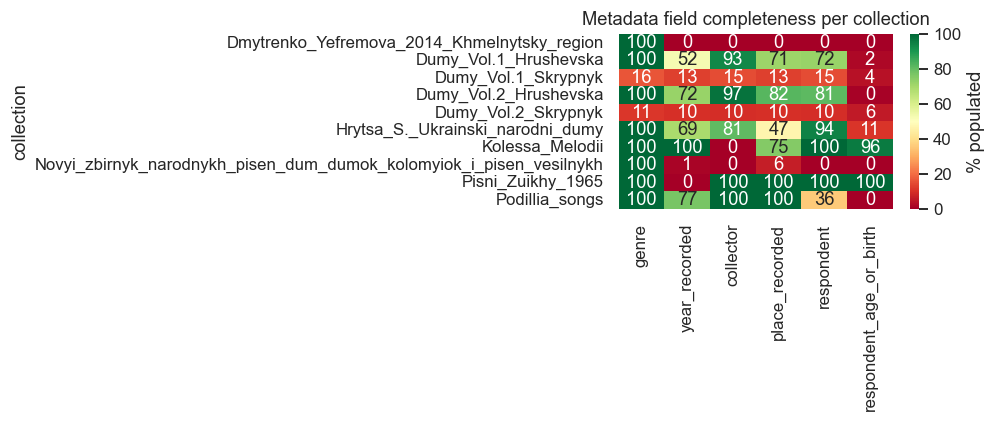

In [26]:
meta_cols = [c for c in ["genre", "year_recorded", "collector",
                         "place_recorded", "respondent",
                         "respondent_age_or_birth"]
             if c in meta_all.columns]
pct_filled = (meta_all.groupby("collection")[meta_cols]
              .apply(lambda g: g.notna().mean() * 100).round(1))
print(pct_filled)

plt.figure(figsize=(9, max(3, 0.4 * len(pct_filled))))
sns.heatmap(pct_filled, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, cbar_kws={"label": "% populated"})
plt.title("Metadata field completeness per collection")
plt.tight_layout(); plt.show()


## 4. Genres, years, places, singers

35 distinct genre labels.
genre
дума                                                            702
родинно-обрядові, весільні                                      533
родинно-побутові, пісні про кохання                             483
родинно-побутові, пісні родинного життя                         290
балади                                                          264
жартівливі та сатиричні                                         221
календарно-обрядові, колядки та щедрівки                        137
календарно-обрядові, веснянки                                   137
танцювальні                                                      79
календарно-обрядові, русальні, петрівчані, купальські            77
календарно-обрядова, русальні, петрівчані, купальські            76
соціально-побутові, рекрутські, солдатські                       59
родинно-побутові, колискові та дитячі                            53
історичні                                                        51
календарно-обряд

C:\Users\hikme\AppData\Local\Temp\ipykernel_20944\2697684218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top.index, x=top.values, palette="viridis")


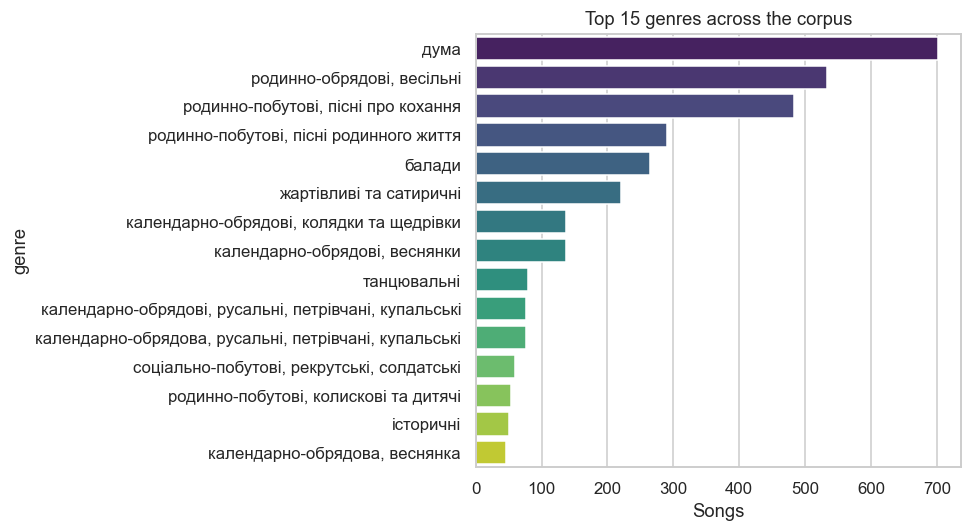

In [27]:
genre_counts = meta_all["genre"].dropna().value_counts()
print(f"{len(genre_counts)} distinct genre labels.")
print(genre_counts.head(20))

top = genre_counts.head(15)
plt.figure(figsize=(9, 5))
sns.barplot(y=top.index, x=top.values, palette="viridis")
plt.xlabel("Songs"); plt.title("Top 15 genres across the corpus")
plt.tight_layout(); plt.show()


Parseable recording year: 1136 / 5284 (21.5%)
Range: 1579–1991, median 1961


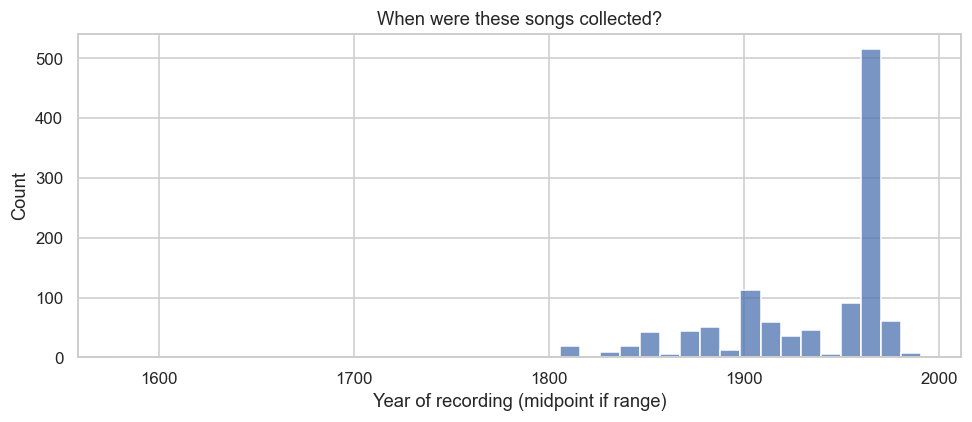

In [28]:
YEAR_RE = re.compile(r"(1[5-9]\d{2}|20[0-2]\d)")

def parse_year(s):
    if pd.isna(s):
        return np.nan
    hits = YEAR_RE.findall(str(s))
    if not hits:
        return np.nan
    # If a range like "1920-1970", take the midpoint for plotting.
    return int(np.mean([int(y) for y in hits]))

meta_all["year_recorded_num"] = meta_all["year_recorded"].apply(parse_year)
yr = meta_all["year_recorded_num"].dropna()
print(f"Parseable recording year: {len(yr)} / {len(meta_all)} "
      f"({len(yr)/len(meta_all)*100:.1f}%)")
if len(yr):
    print(f"Range: {int(yr.min())}–{int(yr.max())}, median {int(yr.median())}")
    plt.figure(figsize=(9, 4))
    sns.histplot(yr, bins=40)
    plt.xlabel("Year of recording (midpoint if range)")
    plt.title("When were these songs collected?")
    plt.tight_layout(); plt.show()


In [29]:
places = meta_all["place_recorded"].dropna().str.strip()
print(f"{places.nunique()} distinct place strings across {len(places)} records.")
print("\nTop 20 recording places (raw strings):")
print(places.value_counts().head(20))
# Note: strings often stack several admin levels (village, district, oblast).
# For the map UI you'll want a normalized place → oblast resolver.


318 distinct place strings across 2306 records.

Top 20 recording places (raw strings):
place_recorded
Ziatkivtsi, Vinnytska oblast                                                                                921
Pohrebyshche, Vinnytska oblast                                                                              850
Миргородщина                                                                                                 15
Лелюхівка, Кобеляцький поз.. Полтавської губ                                                                 11
Миргород                                                                                                     11
с. Лелюхівка Кобеляцького повіту Полтавської губернії (нині Новосанжарського району Полтавської області)     11
Лохвиця на Приліпці                                                                                          10
Костянтиноград (нині Красноград),  Красноградського району Харківської області                                9
с

370 distinct singers across 1826 recordings.
Median songs per singer: 1
Singers with ≥10 songs : 15
Singers with 1 song    : 232

Top 20 singers by song count:
respondent
Yavdokha Zuikha                          921
Софія Присяжнюк                           64
Кравченко М.                              24
К. Кульбіда                               22
кобзар                                    16
Скубій І.                                 16
П. Лагич                                  15
кобзар Іван                               14
група жінок                               13
Марія Білоконь                            12
лірник Іван Скубій                        12
Кравченко П.                              12
Бондаренко М.                             11
Ткаченко Г.                               11
кобзар Остап Вересай                      11
кобзар Андрій Шут                          9
Гребень А.                                 8
Вересай О.                                 8
П. Грузь           

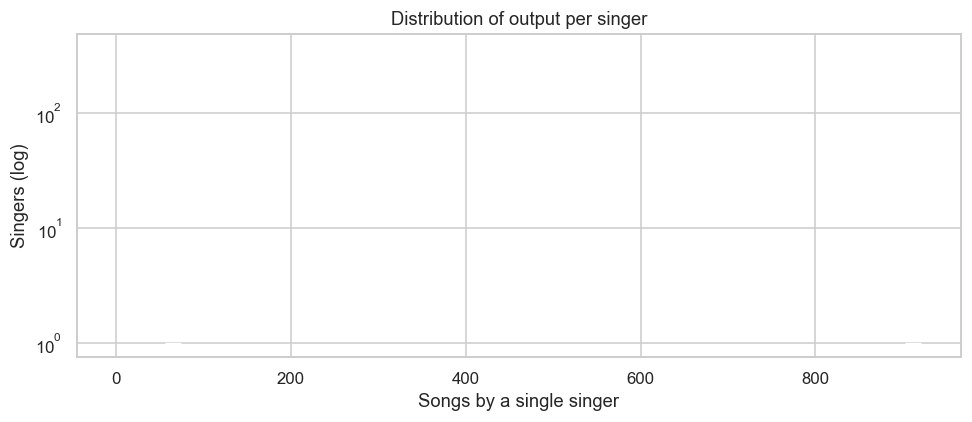

In [30]:
singers = meta_all["respondent"].dropna().str.strip()
per_singer = singers.value_counts()
print(f"{singers.nunique()} distinct singers across {len(singers)} recordings.")
print(f"Median songs per singer: {int(per_singer.median())}")
print(f"Singers with ≥10 songs : {(per_singer >= 10).sum()}")
print(f"Singers with 1 song    : {(per_singer == 1).sum()}")
print("\nTop 20 singers by song count:")
print(per_singer.head(20))

plt.figure(figsize=(9, 4))
sns.histplot(per_singer.values, bins=50, log_scale=(False, True))
plt.xlabel("Songs by a single singer"); plt.ylabel("Singers (log)")
plt.title("Distribution of output per singer")
plt.tight_layout(); plt.show()


In [31]:
if "collector" in meta_all.columns:
    cols = meta_all["collector"].dropna().str.strip()
    print(f"{cols.nunique()} distinct collectors.")
    print("\nTop 15 collectors:")
    print(cols.value_counts().head(15))


160 distinct collectors.

Top 15 collectors:
collector
Hnat Tantsiura         921
Nastia Prysiazhniuk    850
Мартинович П.           66
Сластіон О.             56
Ф. Колесса              29
П. Куліш                27
Колесса Ф.              23
П. Мартинович           21
Харків В.               21
В. Горленко             20
П. Житецький            14
М. Костомаров           13
Горленко В.             12
0. Сластьон             10
Лисенко М.               9
Name: count, dtype: int64


Age known for 118 recordings. Median 53.


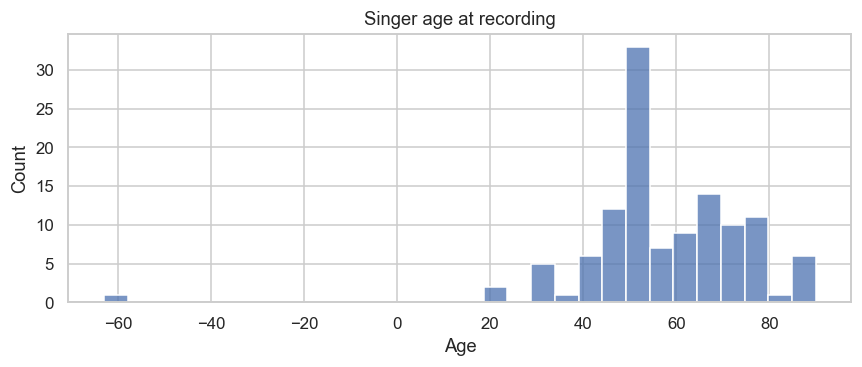

In [32]:
# Age / birth year often appears as "1925 р. н." (born 1925) or "75 р." (age 75).
def parse_age_or_birth(s):
    if pd.isna(s):
        return (np.nan, np.nan)
    s = str(s)
    yr = YEAR_RE.search(s)
    if yr:
        return (int(yr.group()), np.nan)
    m = re.search(r"\b(\d{1,3})\b", s)
    if m:
        age = int(m.group(1))
        if 0 < age < 120:
            return (np.nan, age)
    return (np.nan, np.nan)

if "respondent_age_or_birth" in meta_all.columns:
    parsed = meta_all["respondent_age_or_birth"].apply(parse_age_or_birth)
    meta_all["birth_year"] = [p[0] for p in parsed]
    meta_all["age_at_recording"] = [p[1] for p in parsed]
    mask = (meta_all["age_at_recording"].isna()
            & meta_all["birth_year"].notna()
            & meta_all["year_recorded_num"].notna())
    meta_all.loc[mask, "age_at_recording"] = (
        meta_all.loc[mask, "year_recorded_num"] - meta_all.loc[mask, "birth_year"]
    )
    ages = meta_all["age_at_recording"].dropna()
    print(f"Age known for {len(ages)} recordings. Median {ages.median():.0f}.")
    if len(ages):
        plt.figure(figsize=(8, 3.5))
        sns.histplot(ages, bins=30)
        plt.title("Singer age at recording")
        plt.xlabel("Age"); plt.tight_layout(); plt.show()


## 5. Text-level structure

Texts come line-by-line; roll them up into one row per song with
length / vocabulary stats. These become your *semantic complexity*
features for the UI.


In [33]:
def tokenize(text: str):
    # Unicode letters only — keeps Cyrillic, drops digits and punctuation.
    return re.findall(r"[^\W\d_]+", text.lower(), flags=re.UNICODE)

songs = (text_all.sort_values(["song_id", "pos"])
         .groupby(["collection", "song_id"], sort=False)
         .agg(
             title=("title", lambda s: next((x for x in s if pd.notna(x) and x), None)),
             full_text=("Text", lambda s: "\n".join(str(x) for x in s if pd.notna(x))),
             num_lines=("Text", lambda s: s.notna().sum()),
         ).reset_index())

songs["num_chars"] = songs["full_text"].str.len()
songs["tokens"] = songs["full_text"].apply(tokenize)
songs["num_words"] = songs["tokens"].str.len()
songs["num_unique_words"] = songs["tokens"].apply(lambda xs: len(set(xs)))
songs["ttr"] = np.where(songs["num_words"] > 0,
                        songs["num_unique_words"] / songs["num_words"], np.nan)
songs["avg_line_len_words"] = np.where(
    songs["num_lines"] > 0, songs["num_words"] / songs["num_lines"], np.nan)

print(songs.drop(columns=["tokens", "full_text"]).describe().round(2))


       num_lines  num_chars  num_words  num_unique_words      ttr  avg_line_len_words
count    3557.00    3557.00    3557.00           3557.00  3557.00             3557.00
mean       33.21     944.36     158.79             89.17     0.67                4.94
std        43.16    1465.89     239.23            111.96     0.16               11.03
min         1.00      45.00       5.00              5.00     0.11                1.48
25%        10.00     243.00      42.00             30.00     0.57                3.50
50%        20.00     473.00      82.00             51.00     0.67                4.24
75%        36.00     865.00     153.00             89.00     0.78                5.29
max       539.00   18625.00    2693.00           1282.00     1.00              374.33


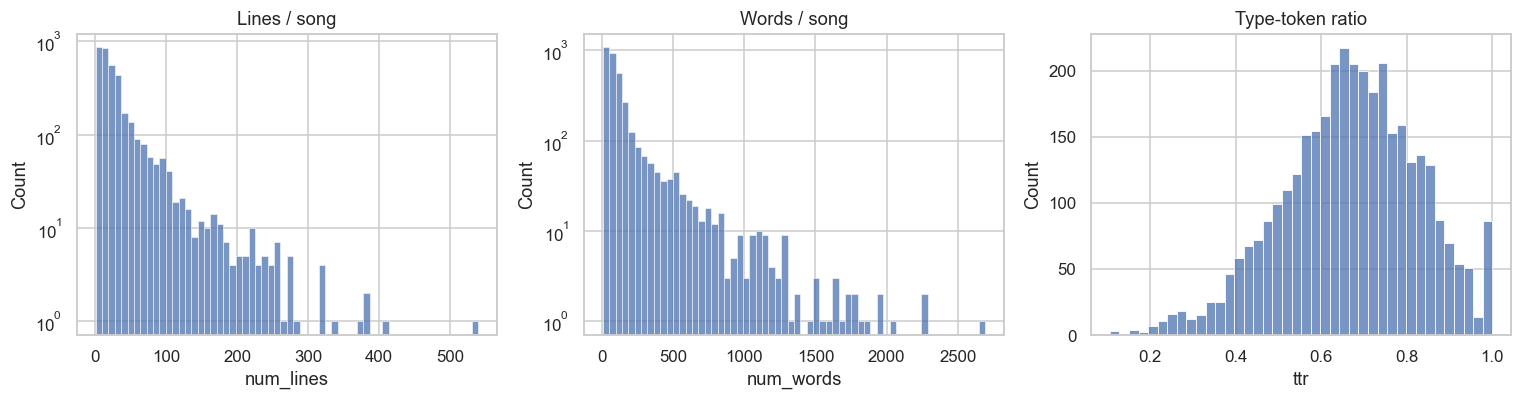

Shortest 5 songs:
                                       collection                    title  num_words
1241  Dmytrenko_Yefremova_2014_Khmelnytsky_region  Найстаршая коровайницьо          5
1409  Dmytrenko_Yefremova_2014_Khmelnytsky_region         Окропи нас, мати          7
350                             Pisni_Zuikhy_1965          ПІЧ НАША РЕГОЧЕ          9
765   Dmytrenko_Yefremova_2014_Khmelnytsky_region       Коло млина кримина          9
1340  Dmytrenko_Yefremova_2014_Khmelnytsky_region            Щедрик-бедрик          9

Longest 5 songs:
                 collection                                              title  num_words
2576    Dumy_Vol.1_Skrypnyk  Писня про славного гетьмана запоризького Кишку...       2693
415   Dumy_Vol.2_Hrushevska                         Про Коновченка вдовиченка.       2289
428   Dumy_Vol.2_Hrushevska                                         Коновченко       2248
148     Dumy_Vol.2_Skrypnyk                                 Тры браты озивськи       205

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
sns.histplot(songs["num_lines"], bins=60, ax=axes[0]); axes[0].set_title("Lines / song")
sns.histplot(songs["num_words"], bins=60, ax=axes[1]); axes[1].set_title("Words / song")
sns.histplot(songs["ttr"].dropna(), bins=40, ax=axes[2]); axes[2].set_title("Type-token ratio")
for ax in axes[:2]:
    ax.set_yscale("log")
plt.tight_layout(); plt.show()

print("Shortest 5 songs:")
print(songs.nsmallest(5, "num_words")[["collection", "title", "num_words"]])
print("\nLongest 5 songs:")
print(songs.nlargest(5, "num_words")[["collection", "title", "num_words"]])


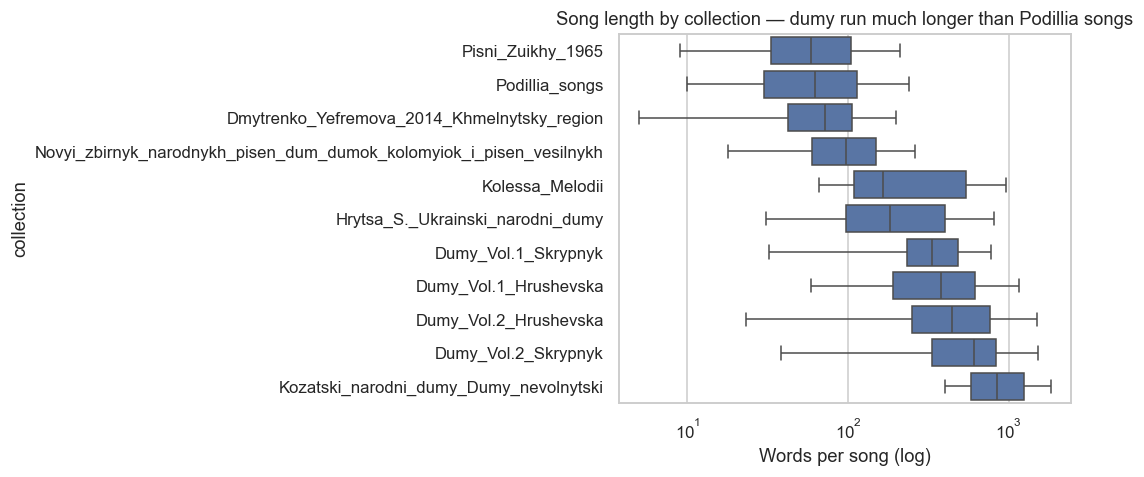

In [35]:
plt.figure(figsize=(10, 4.5))
order = songs.groupby("collection")["num_words"].median().sort_values().index
sns.boxplot(data=songs, y="collection", x="num_words",
            showfliers=False, order=order)
plt.xscale("log")
plt.xlabel("Words per song (log)")
plt.title("Song length by collection — dumy run much longer than Podillia songs")
plt.tight_layout(); plt.show()


## 6. Orthographic systems

The Zenodo description flags **five orthographies** in the dumy
collections — Russian-based 19th-c., *maksymovychivka*, *kulishivka*,
*dragomanivka*, *zhelehivka* — plus modern Ukrainian in Podillia.
Before any embedding / lemmatization step you'll need to know which
collection uses which. A few diagnostic characters give a quick read.


                                                    yery (ы)  hard sign (ъ)  yat (ѣ)  ukrainian_i (і)  yi (ї)  ie (є)  ge_upturn (ґ)  apostrophe (')
collection                                                                                                                                          
Dmytrenko_Yefremova_2014_Khmelnytsky_region            0.008          0.000    0.000           31.682   3.487   4.089          0.002           0.209
Dumy_Vol.1_Hrushevska                                  7.418          9.373    1.915           27.460   2.759   5.497          0.010           0.028
Dumy_Vol.1_Skrypnyk                                   20.424         13.164    1.278           18.730   1.944   4.189          0.006           0.016
Dumy_Vol.2_Hrushevska                                 12.059          8.876    1.417           21.410   2.441   4.138          0.009           0.052
Dumy_Vol.2_Skrypnyk                                   16.709         11.000    1.595           21.645   5.

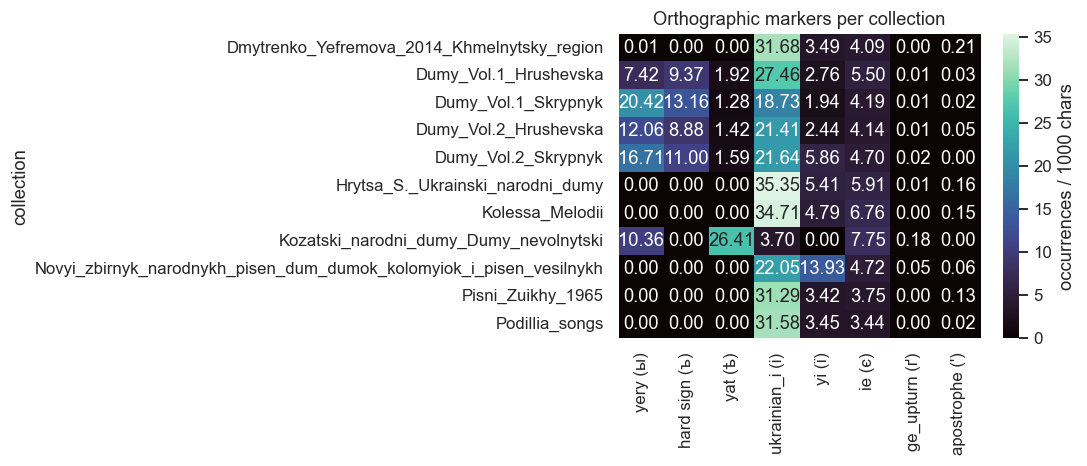

In [36]:
# Characters that disambiguate Ukrainian orthographies / Russian influence.
probes = {
    "yery (ы)":         "ы",   # pre-reform / Russian-influenced
    "hard sign (ъ)":    "ъ",   # pre-reform
    "yat (ѣ)":          "ѣ",   # maksymovychivka / 19c
    "ukrainian_i (і)":  "і",
    "yi (ї)":           "ї",
    "ie (є)":           "є",
    "ge_upturn (ґ)":    "ґ",
    "apostrophe (')":   "'",
}

def char_freq(text, ch):
    if not text:
        return 0.0
    return text.count(ch) / len(text) * 1000  # per 1000 chars

diag = pd.DataFrame({
    label: songs["full_text"].apply(lambda t, c=ch: char_freq(t, c))
    for label, ch in probes.items()
})
diag["collection"] = songs["collection"].values
by_collection = diag.groupby("collection").mean().round(3)
print(by_collection)

plt.figure(figsize=(10, max(3, 0.4 * len(by_collection))))
sns.heatmap(by_collection, annot=True, fmt=".2f", cmap="mako",
            cbar_kws={"label": "occurrences / 1000 chars"})
plt.title("Orthographic markers per collection")
plt.tight_layout(); plt.show()


## 7. Vocabulary & formulaic phrases

Dumy are full of formulaic phrases (the *locus communis* tradition).
Document-frequency n-grams surface them quickly.


In [37]:
global_counter = Counter()
for toks in songs["tokens"]:
    global_counter.update(toks)

print(f"Total tokens   : {sum(global_counter.values()):,}")
print(f"Vocabulary size: {len(global_counter):,}")
hapax = sum(1 for _, c in global_counter.items() if c == 1)
print(f"Hapax legomena : {hapax:,}  ({hapax/len(global_counter)*100:.1f}%)")

print("\nTop 30 tokens — crude Ukrainian stopword preview:")
for w, c in global_counter.most_common(30):
    print(f"  {w:20s} {c}")


Total tokens   : 564,816
Vocabulary size: 54,526
Hapax legomena : 24,471  (44.9%)

Top 30 tokens — crude Ukrainian stopword preview:
  не                   13892
  на                   12111
  а                    9221
  та                   7373
  ой                   7266
  до                   7055
  в                    6915
  то                   6682
  я                    6638
  й                    6596
  у                    5142
  з                    4603
  ти                   4456
  як                   4365
  і                    4025
  за                   3806
  мене                 3419
  що                   3050
  по                   3028
  и                    2718
  гей                  2664
  ж                    2536
  чи                   2003
  да                   1870
  тебе                 1775
  мати                 1769
  бо                   1588
  мені                 1558
  моя                  1540
  ми                   1530


In [38]:
def ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

# Document frequency = share of songs containing the n-gram at least once.
bigram_df = Counter()
trigram_df = Counter()
for toks in songs["tokens"]:
    bigram_df.update(set(ngrams(toks, 2)))
    trigram_df.update(set(ngrams(toks, 3)))

N = len(songs)
print("Top 20 bigrams by document frequency:")
for ng, c in bigram_df.most_common(20):
    print(f"  {c/N*100:5.1f}%  {ng}")
print("\nTop 15 trigrams by document frequency:")
for ng, c in trigram_df.most_common(15):
    print(f"  {c/N*100:5.1f}%  {ng}")


Top 20 bigrams by document frequency:
   28.7%  та й
   13.7%  ще й
   12.4%  а я
    9.1%  а в
    8.9%  й не
    7.1%  то не
    6.9%  ой у
    6.8%  чи не
    6.6%  ой не
    6.5%  ой як
    6.4%  й на
    6.2%  ж ти
    6.0%  та не
    6.0%  а як
    5.5%  що я
    5.3%  я не
    5.3%  як я
    5.3%  я буду
    5.2%  ой на
    5.1%  а на

Top 15 trigrams by document frequency:
    3.5%  та й не
    3.3%  та й на
    2.8%  на поталу не
    2.6%  до отця до
    2.6%  на чорному морі
    2.1%  на многая літа
    1.7%  на три части
    1.7%  ой у полі
    1.7%  ой піду я
    1.5%  та й до
    1.4%  нехай же я
    1.4%  до конця віка
    1.4%  ой то не
    1.3%  за стремена хватає
    1.3%  по чорному морю


## 8. Theme keyword baseline

Crude lexicon baseline — just enough to sanity-check whatever classifier
you train next. Expand the seed lists and replace with a proper model
(zero-shot XLM-R, multilingual NLI, LLM labels) in the real pipeline.


Mean theme-keyword hits per song, by collection:
                                                    love  death  family    war  religion  nature  work
collection                                                                                            
Dmytrenko_Yefremova_2014_Khmelnytsky_region         1.06   0.06    1.54   0.80      0.35    0.95  0.16
Dumy_Vol.1_Hrushevska                               0.49   0.97   14.93   6.42      4.55    3.13  1.20
Dumy_Vol.1_Skrypnyk                                 0.15   0.82    4.65   7.08      5.81    1.88  0.58
Dumy_Vol.2_Hrushevska                               0.90   1.01   13.80  14.23      4.24    6.53  1.38
Dumy_Vol.2_Skrypnyk                                 0.83   1.73   23.90   5.73      1.35    4.38  1.49
Hrytsa_S._Ukrainski_narodni_dumy                    0.28   0.53    9.38   4.02      2.60    2.07  0.58
Kolessa_Melodii                                     0.08   0.08    8.25   3.25      3.08    1.42  0.54
Kozatski_narodni_dumy_Du

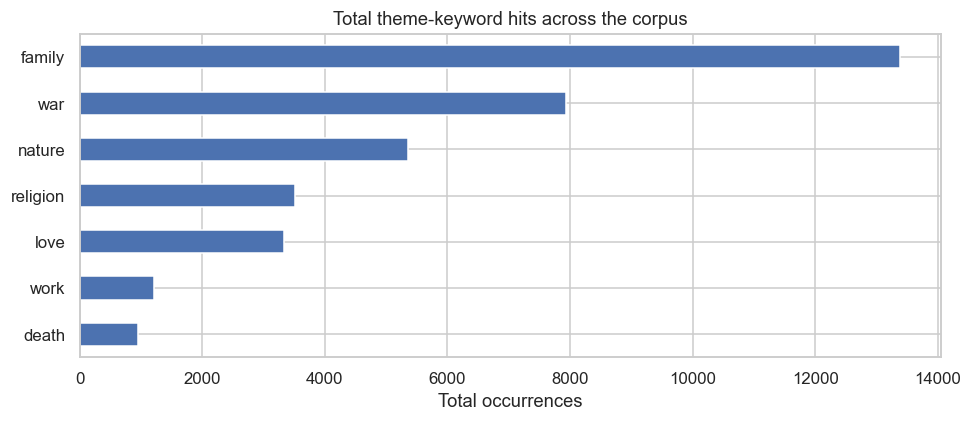

In [39]:
# Seeds are stems matched as substrings inside lowercased tokens,
# so you get morphological coverage for free (люб → любов, любити, …).
THEME_SEEDS = {
    "love":     ["люб", "коха", "милий", "мила", "серц"],
    "death":    ["смерт", "помер", "гроб", "могил", "умир", "умер"],
    "family":   ["мати", "мам", "батьк", "тат", "брат", "сестр", "донь", "син"],
    "war":      ["козак", "війн", "воюв", "турок", "татар", "бит", "шабл", "кон"],
    "religion": ["бог", "господ", "церкв", "свят", "молит", "ангел"],
    "nature":   ["ліс", "степ", "річ", "пол", "дуб", "калин", "верб", "сонце", "місяц"],
    "work":     ["орат", "жат", "коси", "млин", "робот", "працюв"],
}

def theme_hits(tokens):
    joined = " ".join(tokens)
    return {t: sum(joined.count(s) for s in seeds)
            for t, seeds in THEME_SEEDS.items()}

theme_df = pd.DataFrame(songs["tokens"].apply(theme_hits).tolist())
theme_df["collection"] = songs["collection"].values

print("Mean theme-keyword hits per song, by collection:")
print(theme_df.groupby("collection").mean().round(2))

plt.figure(figsize=(9, 4))
theme_df.drop(columns="collection").sum().sort_values().plot.barh()
plt.title("Total theme-keyword hits across the corpus")
plt.xlabel("Total occurrences")
plt.tight_layout(); plt.show()


## 9. Similarity baseline (TF-IDF)

For the Song Map recommendations ("songs like this", "singers like this")
you'll likely use multilingual sentence embeddings. But a
**character-n-gram TF-IDF** baseline is cheap and surprisingly robust
against the orthographic variation above — if these neighbors already
look reasonable, the corpus is clean enough to embed.


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5),
    min_df=3, max_df=0.5, lowercase=True, sublinear_tf=True,
)
X = vec.fit_transform(songs["full_text"].fillna(""))
print("TF-IDF matrix:", X.shape)

query_idx = songs.sample(1, random_state=42).index[0]
sims = cosine_similarity(X[query_idx], X).ravel()
order = np.argsort(-sims)[1:6]
print(f"\nQuery: {songs.loc[query_idx, 'title']!r}  "
      f"({songs.loc[query_idx, 'collection']})\n")
print("Nearest neighbors:")
for i in order:
    print(f"  {sims[i]:.3f}  [{songs.loc[i, 'collection']:30s}] "
          f"{songs.loc[i, 'title']!r}")


TF-IDF matrix: (3557, 102223)

Query: 'ЯСНИЙ МІСЯЦЬ ЗАСВІТИВ ТА ВПАЛА ПОРОША'  (Podillia_songs)

Nearest neighbors:
  0.390  [Dmytrenko_Yefremova_2014_Khmelnytsky_region] 'А в первому юлі'
  0.331  [Dmytrenko_Yefremova_2014_Khmelnytsky_region] 'Задумала стара баба'
  0.219  [Podillia_songs                ] "А ДІДУНЬО ЛЮЛЬКУ КУРЕ, А БАБУНЯ ПІР'Я ДРЕ"
  0.168  [Podillia_songs                ] 'ПІШОВ ДІД НА ОБІД, БАБА НА ХРЕСТИНИ'
  0.168  [Podillia_songs                ] 'ЗАХОТІЛА ВРАЖА БАБА ТА Й ЗАБАГАТІТИ'


## 10. Export a clean working dataset

In [1]:
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

songs_out = songs.drop(columns=["tokens"]).copy()
songs_out.to_parquet(OUT_DIR / "songs_clean.parquet", index=False)

meta_out = meta_all.copy()
meta_out.to_parquet(OUT_DIR / "metadata_clean.parquet", index=False)

singers_profile = (
    meta_all.dropna(subset=["respondent"])
    .groupby("respondent")
    .agg(
        song_count=("song_id", "nunique"),
        collections=("collection", lambda s: sorted(set(s))),
        places=("place_recorded", lambda s: sorted(set(s.dropna()))),
        earliest_year=("year_recorded_num", "min"),
        latest_year=("year_recorded_num", "max"),
    ).reset_index()
    .sort_values("song_count", ascending=False)
)
singers_profile.to_csv(OUT_DIR / "singers_profile.csv", index=False)

print(f"Wrote {OUT_DIR}/songs_clean.parquet    ({len(songs_out):,} rows)")
print(f"Wrote {OUT_DIR}/metadata_clean.parquet ({len(meta_out):,} rows)")
print(f"Wrote {OUT_DIR}/singers_profile.csv    ({len(singers_profile):,} singers)")


NameError: name 'Path' is not defined

## 11. What's next

- **Normalize orthography** on the dumy before embedding — the heatmap
  in §6 tells you which collections need it (ы/ъ/ѣ hot → Russian-based
  or pre-reform, needs transliteration).
- **Build a place → oblast gazetteer** — you need oblast-level keys for
  the regional map.
- **Replace the theme baseline** with zero-shot classification on a
  multilingual NLI model, or LLM few-shot labels; validate the new
  distribution against the lexicon baseline.
- **Swap TF-IDF for sentence embeddings** (LaBSE / multilingual-e5)
  once orthography is normalized, then average singer-level embeddings
  for the "similar singers" recommendation.
- **Re-run this notebook** against Estonian / Finnish / Karelian /
  Ingrian corpora as you add them — only `META_COLS_UA_EN` and the
  orthographic probes are language-specific.


In [14]:
import re
import pandas as pd
from collections import Counter

# -------- 1. Collection-level region (from filenames) --------
# The filename itself carries the coarse region for some collections
# (e.g. "Dmytrenko_Yefremova_2014_Khmelnytsky_region", "Podillia_songs").
# The dumy volumes are pan-Ukrainian epic collections with no single region.
COLLECTION_REGIONS = {
    "Dmytrenko_Yefremova_2014_Khmelnytsky_region": "Khmelnytsky oblast",
    "Pisni_Zuikhy_1965":                           "Vinnytsia oblast (Podillia)",
    "Podillia_songs":                              "Podillia (historical region)",
    # Everything else is dumy — no fixed region
}

print("=" * 60)
print("REGIONS BY COLLECTION")
print("=" * 60)
for name in sorted(meta_all["collection"].unique()):
    region = COLLECTION_REGIONS.get(name, "— pan-Ukrainian (dumy)")
    n_songs = meta_all.loc[meta_all["collection"] == name, "song_id"].nunique()
    print(f"  {name:55s} → {region}   ({n_songs:,} songs)")

# -------- 2. Fine-grained region from place_recorded --------
# The `place_recorded` column (translated from "Місце запису") stores
# strings like "с. Погребище, Погребищенський р-н, Вінницька обл.".
# We extract the oblast (top-level admin unit — the Ukrainian "region").

OBLAST_RE = re.compile(
    r"([А-ЯІЇЄҐ][а-яіїєґ'\-]+(?:\s+[А-ЯІЇЄҐ][а-яіїєґ'\-]+)?)\s*(?:обл\.?|область)",
    flags=re.UNICODE,
)

def extract_oblast(s):
    if not isinstance(s, str):
        return None
    m = OBLAST_RE.search(s)
    return m.group(1).strip() if m else None

place_series = meta_all["place_recorded"].dropna()
meta_all["oblast"] = meta_all["place_recorded"].apply(extract_oblast)

print()
print("=" * 60)
print("OBLASTS EXTRACTED FROM place_recorded")
print("=" * 60)
print(f"Songs with any place string : {place_series.notna().sum():,}")
print(f"Songs with extracted oblast : {meta_all['oblast'].notna().sum():,}")
print(f"Distinct oblasts found      : {meta_all['oblast'].nunique()}\n")

oblast_counts = meta_all["oblast"].dropna().value_counts()
for oblast, n in oblast_counts.items():
    print(f"  {oblast:30s} {n:>4} songs")

# -------- 3. Raw place strings that did NOT parse to an oblast --------
# Useful for tightening the regex — these are typically older pre-1991
# Russian-spelled names ("Подольская губ.") or bare village names.
unparsed = place_series[~place_series.isin(
    meta_all.dropna(subset=["oblast"])["place_recorded"]
)]
print()
print("=" * 60)
print(f"SAMPLE UNPARSED PLACE STRINGS ({len(unparsed):,} total)")
print("=" * 60)
for p in unparsed.drop_duplicates().head(15):
    print(f"  {p}")

REGIONS BY COLLECTION
  Dmytrenko_Yefremova_2014_Khmelnytsky_region             → Khmelnytsky oblast   (991 songs)
  Dumy_Vol.1_Hrushevska                                   → — pan-Ukrainian (dumy)   (118 songs)
  Dumy_Vol.1_Skrypnyk                                     → — pan-Ukrainian (dumy)   (161 songs)
  Dumy_Vol.2_Hrushevska                                   → — pan-Ukrainian (dumy)   (183 songs)
  Dumy_Vol.2_Skrypnyk                                     → — pan-Ukrainian (dumy)   (110 songs)
  Hrytsa_S._Ukrainski_narodni_dumy                        → — pan-Ukrainian (dumy)   (103 songs)
  Kolessa_Melodii                                         → — pan-Ukrainian (dumy)   (24 songs)
  Novyi_zbirnyk_narodnykh_pisen_dum_dumok_kolomyiok_i_pisen_vesilnykh → — pan-Ukrainian (dumy)   (92 songs)
  Pisni_Zuikhy_1965                                       → Vinnytsia oblast (Podillia)   (921 songs)
  Podillia_songs                                          → Podillia (historical region)   (85

In [15]:
# Canonical 24 Ukrainian oblasts (nominative, feminine adjective form).
OBLASTS_CANONICAL = [
    "Вінницька", "Волинська", "Дніпропетровська", "Донецька", "Житомирська",
    "Закарпатська", "Запорізька", "Івано-Франківська", "Київська", "Кіровоградська",
    "Луганська", "Львівська", "Миколаївська", "Одеська", "Полтавська",
    "Рівненська", "Сумська", "Тернопільська", "Харківська", "Херсонська",
    "Хмельницька", "Черкаська", "Чернівецька", "Чернігівська",
]

# Ukrainian feminine adjective case endings after the stem "-ськ-".
CASE_ENDINGS = ("а", "ої", "ій", "у", "ою", "е")  # nom, gen, dat/loc, acc, instr, vocative

def canonicalize_oblast(raw: str) -> str | None:
    """Match an inflected oblast adjective back to its nominative form."""
    if not isinstance(raw, str):
        return None
    # Strip trailing case ending to get the stem, then match against canonical stems.
    for canon in OBLASTS_CANONICAL:
        stem = canon[:-1]  # drop final "а" → "Полтавськ", "Харківськ", …
        for end in CASE_ENDINGS:
            if raw.strip() == stem + end:
                return canon
    return None

meta_all["oblast_canonical"] = meta_all["oblast"].apply(canonicalize_oblast)

matched = meta_all["oblast_canonical"].dropna()
unmatched = meta_all.loc[meta_all["oblast"].notna() & meta_all["oblast_canonical"].isna(), "oblast"]

print(f"Raw distinct strings          : {meta_all['oblast'].nunique()}")
print(f"Canonical oblasts identified  : {matched.nunique()}")
print(f"Unmatched inflections (check) : {unmatched.nunique()}\n")

print("Songs per canonical oblast:")
print(matched.value_counts().to_string())

if unmatched.nunique():
    print("\nUnmatched raw strings (extend CASE_ENDINGS or canonical list):")
    print(unmatched.value_counts().head(10).to_string())

Raw distinct strings          : 18
Canonical oblasts identified  : 7
Unmatched inflections (check) : 9

Songs per canonical oblast:
oblast_canonical
Полтавська      51
Харківська      41
Чернігівська    27
Сумська         10
Черкаська        3
Київська         2
Миколаївська     1

Unmatched raw strings (extend CASE_ENDINGS or canonical list):
oblast
Дніпровської                    2
Сколобів Житомирської           1
Чергінігівської                 1
Поталвської                     1
Мерефа Харківської              1
Черніговської                   1
Борисовка Курської              1
Покровське Дніпропетровської    1
Адамівка Хмельницької           1


In [16]:
import re
import pandas as pd

# -------- 1. Canonical oblast registry (24 modern Ukrainian oblasts) --------
# `ua`  — Ukrainian nominative (adjective form, for display)
# `en`  — English name (for URL slugs, API keys, fallback display)
# `slug`— stable lowercase ID for platform routing/URLs
OBLASTS = [
    {"ua": "Вінницька",        "en": "Vinnytsia",       "slug": "vinnytsia"},
    {"ua": "Волинська",        "en": "Volyn",           "slug": "volyn"},
    {"ua": "Дніпропетровська", "en": "Dnipropetrovsk",  "slug": "dnipropetrovsk"},
    {"ua": "Донецька",         "en": "Donetsk",         "slug": "donetsk"},
    {"ua": "Житомирська",      "en": "Zhytomyr",        "slug": "zhytomyr"},
    {"ua": "Закарпатська",     "en": "Zakarpattia",     "slug": "zakarpattia"},
    {"ua": "Запорізька",       "en": "Zaporizhzhia",    "slug": "zaporizhzhia"},
    {"ua": "Івано-Франківська","en": "Ivano-Frankivsk", "slug": "ivano-frankivsk"},
    {"ua": "Київська",         "en": "Kyiv",            "slug": "kyiv"},
    {"ua": "Кіровоградська",   "en": "Kirovohrad",      "slug": "kirovohrad"},
    {"ua": "Луганська",        "en": "Luhansk",         "slug": "luhansk"},
    {"ua": "Львівська",        "en": "Lviv",            "slug": "lviv"},
    {"ua": "Миколаївська",     "en": "Mykolaiv",        "slug": "mykolaiv"},
    {"ua": "Одеська",          "en": "Odesa",           "slug": "odesa"},
    {"ua": "Полтавська",       "en": "Poltava",         "slug": "poltava"},
    {"ua": "Рівненська",       "en": "Rivne",           "slug": "rivne"},
    {"ua": "Сумська",          "en": "Sumy",            "slug": "sumy"},
    {"ua": "Тернопільська",    "en": "Ternopil",        "slug": "ternopil"},
    {"ua": "Харківська",       "en": "Kharkiv",         "slug": "kharkiv"},
    {"ua": "Херсонська",       "en": "Kherson",         "slug": "kherson"},
    {"ua": "Хмельницька",      "en": "Khmelnytskyi",    "slug": "khmelnytskyi"},
    {"ua": "Черкаська",        "en": "Cherkasy",        "slug": "cherkasy"},
    {"ua": "Чернівецька",      "en": "Chernivtsi",      "slug": "chernivtsi"},
    {"ua": "Чернігівська",     "en": "Chernihiv",       "slug": "chernihiv"},
]
OBLAST_DF = pd.DataFrame(OBLASTS)

# -------- 2. Explicit mapping from every raw string → canonical oblast --------
# Built by auditing the actual values in your data. Fixes: inflection,
# typos, village-name prefixes, old governorate spellings.
RAW_TO_CANONICAL_UA = {
    # — already canonical inflections —
    "Полтавської":      "Полтавська",
    "Харківської":      "Харківська",
    "Чернігівської":    "Чернігівська",
    "Сумської":         "Сумська",
    "Черкаської":       "Черкаська",
    "Київської":        "Київська",
    "Миколаївської":    "Миколаївська",
    "Хмельницької":     "Хмельницька",
    "Житомирської":     "Житомирська",
    "Дніпропетровської":"Дніпропетровська",
    # — typos / alt spellings (keep the left side EXACTLY as it appears in data) —
    "Чергінігівської":  "Чернігівська",   # typo: Черг-і-нігівської
    "Поталвської":      "Полтавська",     # typo: letters swapped
    "Черніговської":    "Чернігівська",   # Russian-style spelling without "ї"
    # — colloquial short form: Dnipropetrovsk oblast often called "Dnipro" —
    "Дніпровської":     "Дніпропетровська",
    # — village-prefix rows (after we strip the village, these match) —
    # These four are produced by the extractor below, not direct lookups.

    # — deliberately NOT mapped: non-Ukrainian oblasts —
    # "Курської":  Kursk oblast is in Russia, not modern Ukraine.
}

# -------- 3. Extractor that handles "Village Oblast-genitive" strings --------
# Ukrainian feminine adjective genitive endings (plus a few dative/locative variants
# that appeared in your data).
OBLAST_STEM_RE = re.compile(
    r"\b([А-ЯІЇЄҐ][а-яіїєґ'\-]+(?:-[А-ЯІЇЄҐ][а-яіїєґ'\-]+)?(?:ськ|цьк))(?:ої|ій|ою|ої|у)",
    flags=re.UNICODE,
)

def raw_to_oblast_ua(raw: str) -> str | None:
    """Resolve any raw oblast string (inflected, typo'd, or village-prefixed)
    to the canonical Ukrainian oblast name, or None if it doesn't resolve."""
    if not isinstance(raw, str):
        return None
    raw = raw.strip()

    # First pass: direct lookup — catches canonical cases and typos.
    if raw in RAW_TO_CANONICAL_UA:
        return RAW_TO_CANONICAL_UA[raw]

    # Second pass: find an oblast adjective anywhere in the string (handles
    # "Мерефа Харківської", "Покровське Дніпропетровської", etc.)
    m = OBLAST_STEM_RE.search(raw)
    if m:
        candidate = m.group(1) + "а"  # reconstruct nominative: -ськ → -ська
        if candidate in OBLAST_DF["ua"].values:
            return candidate

    return None

# -------- 4. Apply and build the platform-ready table --------
meta_all["oblast_ua"] = meta_all["oblast"].apply(raw_to_oblast_ua)

counts = (meta_all.dropna(subset=["oblast_ua"])
                  .drop_duplicates(subset=["song_id", "oblast_ua"])
                  .groupby("oblast_ua")["song_id"].nunique()
                  .rename("song_count"))

platform_table = (OBLAST_DF.merge(counts, left_on="ua", right_index=True, how="left")
                           .fillna({"song_count": 0}))
platform_table["song_count"] = platform_table["song_count"].astype(int)
platform_table["has_songs"] = platform_table["song_count"] > 0

# -------- 5. Show results --------
in_corpus = platform_table[platform_table["has_songs"]].sort_values("song_count", ascending=False)
print(f"Oblasts present in corpus: {len(in_corpus)} of 24")
print(f"Total songs geolocated to an oblast: {in_corpus['song_count'].sum()}\n")
print(in_corpus[["ua", "en", "slug", "song_count"]].to_string(index=False))

# Sanity check: did anything still fail to resolve?
still_unmatched = (meta_all[meta_all["oblast"].notna() & meta_all["oblast_ua"].isna()]
                   ["oblast"].value_counts())
if len(still_unmatched):
    print(f"\nStill unresolved ({len(still_unmatched)} distinct strings):")
    print(still_unmatched.to_string())

Oblasts present in corpus: 10 of 24
Total songs geolocated to an oblast: 137

              ua             en           slug  song_count
      Полтавська        Poltava        poltava          52
      Харківська        Kharkiv        kharkiv          42
    Чернігівська      Chernihiv      chernihiv          24
         Сумська           Sumy           sumy           8
       Черкаська       Cherkasy       cherkasy           3
Дніпропетровська Dnipropetrovsk dnipropetrovsk           3
        Київська           Kyiv           kyiv           2
     Житомирська       Zhytomyr       zhytomyr           1
    Миколаївська       Mykolaiv       mykolaiv           1
     Хмельницька   Khmelnytskyi   khmelnytskyi           1

Still unresolved (3 distinct strings):
oblast
Чернігівська          5
Сумська               2
Борисовка Курської    1


In [18]:
import re
import pandas as pd

# ── Strategy 0: oblast registry ────────────────────────────────────────────
OBLASTS = [
    ("Вінницька","Vinnytsia","vinnytsia"), ("Волинська","Volyn","volyn"),
    ("Дніпропетровська","Dnipropetrovsk","dnipropetrovsk"), ("Донецька","Donetsk","donetsk"),
    ("Житомирська","Zhytomyr","zhytomyr"), ("Закарпатська","Zakarpattia","zakarpattia"),
    ("Запорізька","Zaporizhzhia","zaporizhzhia"), ("Івано-Франківська","Ivano-Frankivsk","ivano-frankivsk"),
    ("Київська","Kyiv","kyiv"), ("Кіровоградська","Kirovohrad","kirovohrad"),
    ("Луганська","Luhansk","luhansk"), ("Львівська","Lviv","lviv"),
    ("Миколаївська","Mykolaiv","mykolaiv"), ("Одеська","Odesa","odesa"),
    ("Полтавська","Poltava","poltava"), ("Рівненська","Rivne","rivne"),
    ("Сумська","Sumy","sumy"), ("Тернопільська","Ternopil","ternopil"),
    ("Харківська","Kharkiv","kharkiv"), ("Херсонська","Kherson","kherson"),
    ("Хмельницька","Khmelnytskyi","khmelnytskyi"), ("Черкаська","Cherkasy","cherkasy"),
    ("Чернівецька","Chernivtsi","chernivtsi"), ("Чернігівська","Chernihiv","chernihiv"),
]
OBLAST_DF = pd.DataFrame(OBLASTS, columns=["ua","en","slug"])
UA_STEMS = {ua.rstrip("а"): ua for ua,_,_ in OBLASTS}  # "Полтавськ" → "Полтавська"
EN_LOWER = {en.lower(): ua for ua,en,_ in OBLASTS}     # "vinnytsia" → "Вінницька"

# Historical governorate → modern oblast (approximate; enough for this corpus).
GOVERNORATE_MAP = {
    "Полтавської":    "Полтавська",
    "Харківської":    "Харківська",
    "Чернігівської":  "Чернігівська",
    "Київської":      "Київська",
    "Подільської":    "Хмельницька",   # Podolia gub ≈ modern Khmelnytskyi/Vinnytsia
    "Волинської":     "Волинська",
    "Катеринославської": "Дніпропетровська",
    "Таврійської":    "Херсонська",
}

# Town / village → modern oblast gazetteer. Add as the "unresolved" list grows.
TOWN_MAP = {
    "Коломиї":    "Івано-Франківська",
    "Коломия":    "Івано-Франківська",
    "Бережан":    "Тернопільська",
    "Бережани":   "Тернопільська",
    "Золочева":   "Львівська",
    "Золочів":    "Львівська",
    "Підгірян":   "Івано-Франківська",   # Підгір'я region, approximate
    "Сорочинці":  "Полтавська",
    "Лелюхівка":  "Полтавська",
    "Перемишля":  None,                   # Przemyśl → modern Poland; exclude
    # extend as needed
}

# Collection → default oblast when the row is blank.
COLLECTION_DEFAULT_OBLAST = {
    "Dmytrenko_Yefremova_2014_Khmelnytsky_region": "Хмельницька",
    "Pisni_Zuikhy_1965":                           "Вінницька",
    "Podillia_songs":                              "Вінницька",
    # Kolessa, Novyi_zbirnyk, and the dumy volumes → no single default; leave None
}

# ── Strategy 1: Latin transliterated — "Place, Xska(ya) oblast" ────────────
LATIN_OBLAST_RE = re.compile(
    r",\s*([A-Za-z'\-]+?(?:s'?|z)kaya?)\s+oblast",
    flags=re.IGNORECASE,
)
LATIN_TO_UA = {
    "vinnytska": "Вінницька", "volynska": "Волинська",
    "dnipropetrovska": "Дніпропетровська", "donetska": "Донецька",
    "zhytomyrska": "Житомирська", "zakarpatska": "Закарпатська",
    "zaporizka": "Запорізька", "ivano-frankivska": "Івано-Франківська",
    "kyivska": "Київська", "kirovohradska": "Кіровоградська",
    "luhanska": "Луганська", "lvivska": "Львівська",
    "mykolaivska": "Миколаївська", "odeska": "Одеська",
    "poltavska": "Полтавська", "rivnenska": "Рівненська",
    "sumska": "Сумська", "ternopilska": "Тернопільська",
    "kharkivska": "Харківська", "khersonska": "Херсонська",
    "khmelnytska": "Хмельницька", "cherkaska": "Черкаська",
    "chernivetska": "Чернівецька", "chernihivska": "Чернігівська",
}

# ── Strategy 2: Cyrillic "Xська обл." ──────────────────────────────────────
CYR_OBLAST_RE = re.compile(
    r"\b([А-ЯІЇЄҐ][а-яіїєґ'\-]+(?:[-][А-ЯІЇЄҐ][а-яіїєґ'\-]+)?(?:ськ|цьк))(?:ої|ій|у|ою|а)?\s*(?:обл\.?|область)",
    flags=re.UNICODE,
)

# ── Strategy 3: Cyrillic governorate "Xської губ" ──────────────────────────
CYR_GUB_RE = re.compile(
    r"\b([А-ЯІЇЄҐ][а-яіїєґ'\-]+(?:ської|цької))\s*губ",
    flags=re.UNICODE,
)

# ── Main resolver ──────────────────────────────────────────────────────────
def resolve_oblast(place: str | None, collection: str | None) -> tuple[str | None, str]:
    """Return (ua_oblast, strategy_used). Strategies tried in order of precision."""
    if isinstance(place, str) and place.strip():
        p = place.strip()

        # 1) Latin transliterated
        m = LATIN_OBLAST_RE.search(p)
        if m and m.group(1).lower() in LATIN_TO_UA:
            return LATIN_TO_UA[m.group(1).lower()], "latin"

        # 2) Cyrillic modern oblast
        m = CYR_OBLAST_RE.search(p)
        if m:
            stem = m.group(1)
            if stem in UA_STEMS:
                return UA_STEMS[stem], "cyrillic_oblast"

        # 3) Cyrillic governorate
        m = CYR_GUB_RE.search(p)
        if m and m.group(1) in GOVERNORATE_MAP:
            return GOVERNORATE_MAP[m.group(1)], "governorate"

        # 4) Bare town — check every token
        for token in re.findall(r"[А-ЯІЇЄҐ][а-яіїєґ'\-]+", p):
            if token in TOWN_MAP:
                return TOWN_MAP[token], "town_gazetteer"

    # 5) Collection-level fallback
    if collection in COLLECTION_DEFAULT_OBLAST:
        return COLLECTION_DEFAULT_OBLAST[collection], "collection_default"

    return None, "unresolved"


# ── Apply to your unified metadata ─────────────────────────────────────────
# meta_all must have columns: song_id, collection, place_recorded, respondent
meta_all[["oblast_ua", "resolution_strategy"]] = meta_all.apply(
    lambda r: pd.Series(resolve_oblast(r.get("place_recorded"), r.get("collection"))),
    axis=1,
)

# Add English name and slug for the platform
meta_all = meta_all.merge(OBLAST_DF, left_on="oblast_ua", right_on="ua", how="left")

# ── Aggregate to singer ───────────────────────────────────────────────────
singers_with_region = (
    meta_all.dropna(subset=["respondent"])
            .groupby("respondent")
            .agg(
                song_count=("song_id", "nunique"),
                oblasts_ua=("oblast_ua", lambda s: sorted(set(s.dropna()))),
                collections=("collection", lambda s: sorted(set(s))),
            )
            .reset_index()
)
# Since every singer in this corpus has exactly one oblast, flatten:
singers_with_region["oblast_ua"] = singers_with_region["oblasts_ua"].apply(
    lambda lst: lst[0] if len(lst) == 1 else None
)
singers_with_region = singers_with_region.merge(
    OBLAST_DF, left_on="oblast_ua", right_on="ua", how="left"
)

print(f"Singers with a resolved region: "
      f"{singers_with_region['oblast_ua'].notna().sum()} of {len(singers_with_region)}")
print(f"\nPer-song resolution strategies:")
print(meta_all["resolution_strategy"].value_counts().to_string())

# What's still unresolved — grow the gazetteers from this list
unresolved = (meta_all[meta_all["resolution_strategy"] == "unresolved"]
              [["collection", "place_recorded"]].drop_duplicates())
print(f"\nUnresolved place strings ({len(unresolved)}):")
print(unresolved.to_string(index=False) if len(unresolved) else "  (none)")

# Singers with their region, ready for the platform
print(f"\nTop singers with region:")
print(singers_with_region.nlargest(15, "song_count")
      [["respondent", "song_count", "oblast_ua", "en", "slug"]].to_string(index=False))

Singers with a resolved region: 213 of 370

Per-song resolution strategies:
resolution_strategy
collection_default    2762
unresolved            2278
cyrillic_oblast        139
governorate             83
town_gazetteer          22

Unresolved place strings (211):
                                                         collection                                                                                       place_recorded
                                              Dumy_Vol.1_Hrushevska                                                                                           м. Охтирка
                                              Dumy_Vol.1_Hrushevska                                                                                                  NaN
                                              Dumy_Vol.1_Hrushevska                                                                           c. Сосниця ( Чернігівщина)
                                              Dumy_Vol.1_Hru